In [ ]:
# ячейка 2 — загрузка датасета
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
print("Path:", path)

# посмотреть структуру
genres_path = os.path.join(path, "Data", "genres_original")
genres = os.listdir(genres_path)
genres.sort()
print(f"\nЖанрлар ({len(genres)}): {genres}")

# сколько файлов в каждом жанре
for g in genres:
    files = os.listdir(os.path.join(genres_path, g))
    print(f"  {g}: {len(files)} файл")

100%|██████████| 1.21G/1.21G [01:17<00:00, 16.8MB/s]

Extracting files...


Path: /home/codespace/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1

Жанрлар (10): ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
  blues: 100 файл
  classical: 100 файл
  country: 100 файл
  disco: 100 файл
  hiphop: 100 файл
  jazz: 100 файл
  metal: 100 файл
  pop: 100 файл
  reggae: 100 файл
  rock: 100 файл


In [ ]:
# ячейка 3 — послушаем один трек и посмотрим waveform
import IPython.display as ipd

# загрузить один трек
sample_file = os.path.join(genres_path, "rock", "rock.00000.wav")
y_audio, sr = librosa.load(sample_file, duration=30)

print(f"Sample rate: {sr}")
print(f"Длина аудио: {len(y_audio)} сэмплов ({len(y_audio)/sr:.1f} сек)")

# послушать
ipd.Audio(y_audio, rate=sr)

Sample rate: 22050
Длина аудио: 661500 сэмплов (30.0 сек)


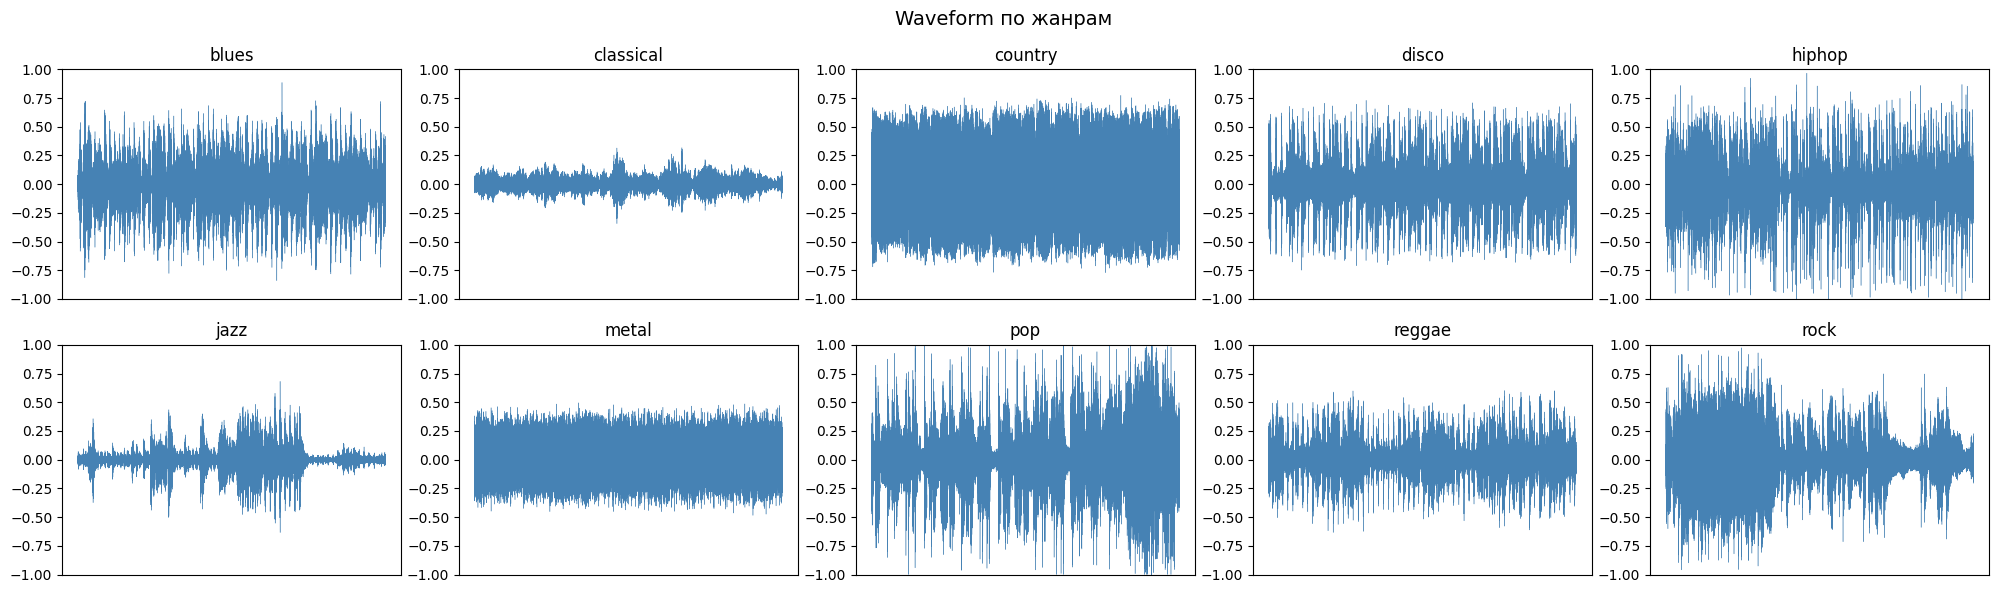

In [4]:
# ячейка 4 — waveform для разных жанров
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()

for i, genre in enumerate(genres):
    file = os.path.join(genres_path, genre, f"{genre}.00000.wav")
    y_audio, sr = librosa.load(file, duration=30)
    axes[i].plot(y_audio, color='steelblue', linewidth=0.3)
    axes[i].set_title(genre)
    axes[i].set_ylim(-1, 1)
    axes[i].set_xticks([])

plt.suptitle('Waveform по жанрам', fontsize=14)
plt.tight_layout()
plt.show()

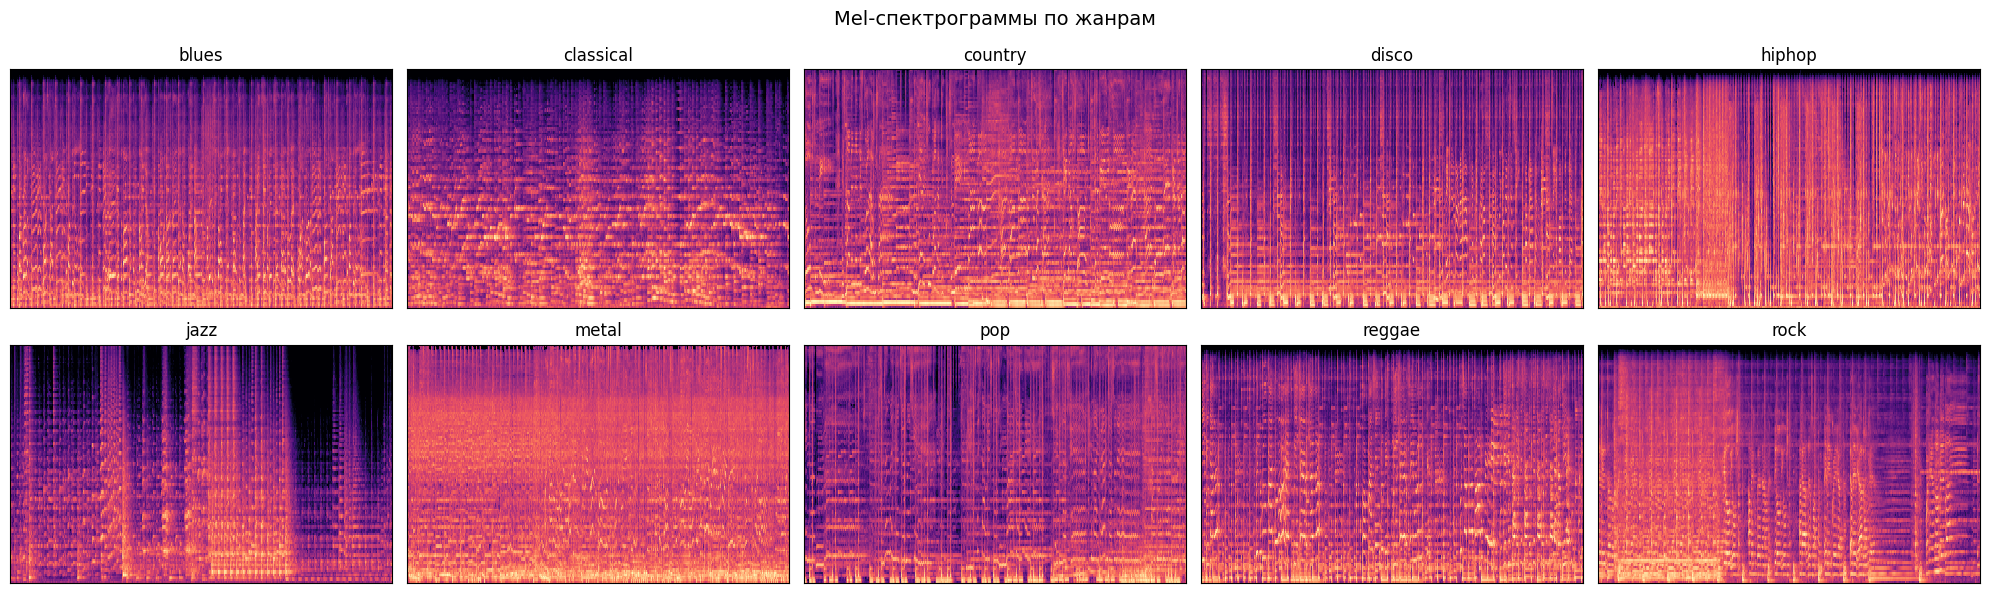

In [5]:
# ячейка 5 — Mel-спектрограммы для разных жанров
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()

for i, genre in enumerate(genres):
    file = os.path.join(genres_path, genre, f"{genre}.00000.wav")
    y_audio, sr = librosa.load(file, duration=30)
    mel_spec = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_spec_db, sr=sr, ax=axes[i], cmap='magma')
    axes[i].set_title(genre)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Mel-спектрограммы по жанрам', fontsize=14)
plt.tight_layout()
plt.show()

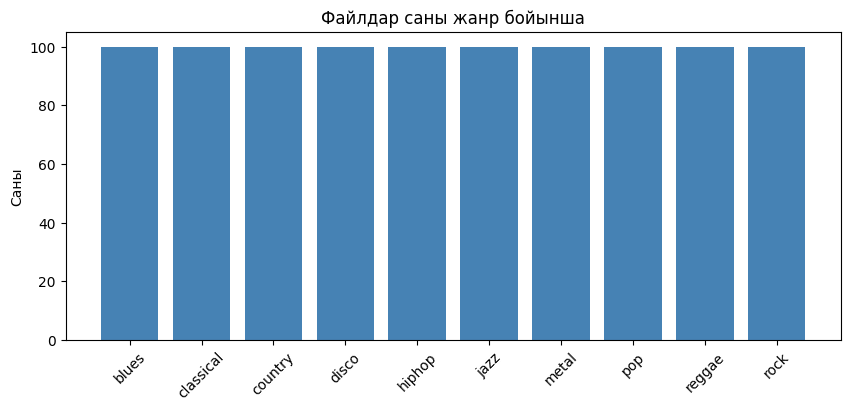

Класстар теңгерімді — SMOTE қажет емес ✅


In [6]:
# ячейка 6 — распределение жанров (баланс классов)
genre_counts = {g: len(os.listdir(os.path.join(genres_path, g))) for g in genres}

plt.figure(figsize=(10, 4))
plt.bar(genre_counts.keys(), genre_counts.values(), color='steelblue')
plt.title('Файлдар саны жанр бойынша')
plt.ylabel('Саны')
plt.xticks(rotation=45)
plt.show()

print("Класстар теңгерімді — SMOTE қажет емес ✅")

In [9]:
# ячейка 7 — конвертация всех аудио в mel-спектрограммы
def audio_to_melspec(file_path, n_mels=128, max_len=128):
    """Аудио файлды mel-спектрограммаға айналдыру"""
    try:
        y_audio, sr = librosa.load(file_path, duration=30)
        mel_spec = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # бірдей өлшемге келтіру (pad немесе crop)
        if mel_spec_db.shape[1] < max_len:
            mel_spec_db = np.pad(mel_spec_db, ((0,0), (0, max_len - mel_spec_db.shape[1])))
        else:
            mel_spec_db = mel_spec_db[:, :max_len]

        return mel_spec_db
    except Exception as e:
        print(f"Қате: {file_path} — {e}")
        return None

# тест
sample = audio_to_melspec(os.path.join(genres_path, "rock", "rock.00000.wav"))
print(f"Спектрограмма өлшемі: {sample.shape}")  # (128, 128)

Спектрограмма өлшемі: (128, 128)


In [10]:
# ячейка 8 — барлық файлдарды өңдеу
X = []
y = []
skipped = 0

for genre in genres:
    genre_dir = os.path.join(genres_path, genre)
    for file_name in os.listdir(genre_dir):
        if not file_name.endswith('.wav'):
            continue
        file_path = os.path.join(genre_dir, file_name)
        mel_spec = audio_to_melspec(file_path)

        if mel_spec is not None:
            X.append(mel_spec)
            y.append(genre)
        else:
            skipped += 1

X = np.array(X)
y = np.array(y)

print(f"Өңделді: {len(X)} файл")
print(f"Өткізілді: {skipped} файл")
print(f"X shape: {X.shape}")  # (999, 128, 128)

/tmp/ipykernel_66324/4246691669.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y_audio, sr = librosa.load(file_path, duration=30)


Қате: /home/codespace/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data/genres_original/jazz/jazz.00054.wav — 
Өңделді: 999 файл
Өткізілді: 1 файл
X shape: (999, 128, 128)


In [11]:
# ячейка 9 — label encoding + train/test split
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Класстар: {le.classes_}")
print(f"Кодтар: {np.unique(y_encoded)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTrain: {X_train.shape}")
print(f"Test: {X_test.shape}")

Класстар: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Кодтар: [0 1 2 3 4 5 6 7 8 9]

Train: (799, 128, 128)
Test: (200, 128, 128)


In [12]:
# ячейка 10 — тензорларға айналдыру
# CNN-ге channel керек: (batch, 1, 128, 128)
X_train_tensor = torch.FloatTensor(X_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test).unsqueeze(1)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Train tensor: {X_train_tensor.shape}")  # (799, 1, 128, 128)
print(f"Test tensor: {X_test_tensor.shape}")     # (200, 1, 128, 128)
print("Тензорлар дайын ✅")

Train tensor: torch.Size([799, 1, 128, 128])
Test tensor: torch.Size([200, 1, 128, 128])
Тензорлар дайын ✅


In [13]:
# ячейка 11 — архитектура CNN
class MusicCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(MusicCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1: (1, 128, 128) → (16, 64, 64)
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: (16, 64, 64) → (32, 32, 32)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: (32, 32, 32) → (64, 16, 16)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4: (64, 16, 16) → (128, 8, 8)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_cnn = MusicCNN()
print(model_cnn)
print(f"\nПараметрлер: {sum(p.numel() for p in model_cnn.parameters()):,}")

MusicCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=Tr

In [14]:
# ячейка 12 — обучение CNN
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

epochs = 40
train_losses = []

for epoch in range(epochs):
    model_cnn.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_cnn(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

print("\nОқыту аяқталды ✅")

Epoch 10/40 — Loss: 0.7799
Epoch 20/40 — Loss: 0.2538
Epoch 30/40 — Loss: 0.0848
Epoch 40/40 — Loss: 0.1084

Оқыту аяқталды ✅


In [16]:
# ячейка 13 — оценка CNN
from sklearn.metrics import classification_report, accuracy_score, f1_score

model_cnn.eval()
with torch.no_grad():
    outputs = model_cnn(X_test_tensor)
    _, y_pred_cnn = torch.max(outputs, 1)
    y_pred_cnn = y_pred_cnn.numpy()

acc_cnn = accuracy_score(y_test, y_pred_cnn)
f1_cnn = f1_score(y_test, y_pred_cnn, average='weighted')

print("=== CNN нәтижелері ===")
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))
print(f"Accuracy: {acc_cnn:.4f}")
print(f"F1-score (weighted): {f1_cnn:.4f}")

=== CNN нәтижелері ===
              precision    recall  f1-score   support

       blues       0.78      0.35      0.48        20
   classical       0.88      0.70      0.78        20
     country       0.52      0.65      0.58        20
       disco       0.45      0.50      0.48        20
      hiphop       0.63      0.85      0.72        20
        jazz       0.72      0.65      0.68        20
       metal       0.71      1.00      0.83        20
         pop       0.50      0.60      0.55        20
      reggae       0.75      0.30      0.43        20
        rock       0.43      0.50      0.47        20

    accuracy                           0.61       200
   macro avg       0.64      0.61      0.60       200
weighted avg       0.64      0.61      0.60       200

Accuracy: 0.6100
F1-score (weighted): 0.5995


In [17]:
# ячейка 14 — ResNet18 архитектурасы
from torchvision import models

model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 1 канал үшін бірінші қабатты өзгерту (RGB емес, grayscale)
model_resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# соңғы қабат — 10 класс
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(512, 10)
)

print(f"Параметрлер: {sum(p.numel() for p in model_resnet.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/codespace/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 355MB/s]

Параметрлер: 11,175,370


In [18]:
# ячейка 15 — обучение ResNet18
criterion = nn.CrossEntropyLoss()
optimizer_res = torch.optim.Adam(model_resnet.parameters(), lr=0.0005)

epochs = 40
train_losses_res = []

for epoch in range(epochs):
    model_resnet.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer_res.zero_grad()
        outputs = model_resnet(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_res.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses_res.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

print("\nОқыту аяқталды ✅")

Epoch 10/40 — Loss: 0.1373
Epoch 20/40 — Loss: 0.0090
Epoch 30/40 — Loss: 0.1343
Epoch 40/40 — Loss: 0.0041

Оқыту аяқталды ✅


In [19]:
# ячейка 16 — оценка ResNet18
model_resnet.eval()
with torch.no_grad():
    outputs = model_resnet(X_test_tensor)
    _, y_pred_res = torch.max(outputs, 1)
    y_pred_res = y_pred_res.numpy()

acc_res = accuracy_score(y_test, y_pred_res)
f1_res = f1_score(y_test, y_pred_res, average='weighted')

print("=== ResNet18 нәтижелері ===")
print(classification_report(y_test, y_pred_res, target_names=le.classes_))
print(f"Accuracy: {acc_res:.4f}")
print(f"F1-score (weighted): {f1_res:.4f}")

=== ResNet18 нәтижелері ===
              precision    recall  f1-score   support

       blues       0.75      0.60      0.67        20
   classical       0.85      0.85      0.85        20
     country       0.73      0.55      0.63        20
       disco       0.50      0.60      0.55        20
      hiphop       0.68      0.65      0.67        20
        jazz       0.76      0.80      0.78        20
       metal       0.86      0.90      0.88        20
         pop       0.48      0.60      0.53        20
      reggae       0.55      0.60      0.57        20
        rock       0.59      0.50      0.54        20

    accuracy                           0.67       200
   macro avg       0.68      0.66      0.67       200
weighted avg       0.68      0.67      0.67       200

Accuracy: 0.6650
F1-score (weighted): 0.6661


In [20]:
# ячейка 17 — таблица сравнения
results = {
    'Модель': ['CNN (с нуля)', 'ResNet18 (Transfer Learning)'],
    'Accuracy': [acc_cnn, acc_res],
    'F1-score': [f1_cnn, f1_res],
    'Параметрлер': ['2.2M', '11.2M']
}

df_results = pd.DataFrame(results)
print("=== Модельдерді салыстыру ===")
print(df_results.to_string(index=False))

=== Модельдерді салыстыру ===
                      Модель  Accuracy  F1-score Параметрлер
                CNN (с нуля)     0.610   0.59946        2.2M
ResNet18 (Transfer Learning)     0.665   0.66612       11.2M


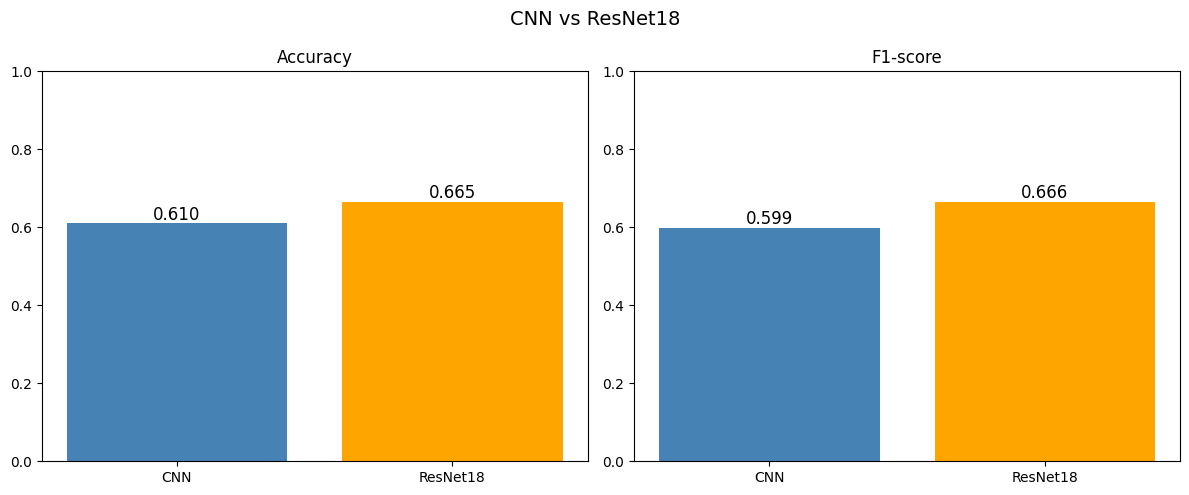

In [21]:
# ячейка 18 — визуальное сравнение метрик
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'orange']

for i, metric in enumerate(['Accuracy', 'F1-score']):
    values = df_results[metric].values
    bars = axes[i].bar(['CNN', 'ResNet18'], values, color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=12)

plt.suptitle('CNN vs ResNet18', fontsize=14)
plt.tight_layout()
plt.show()

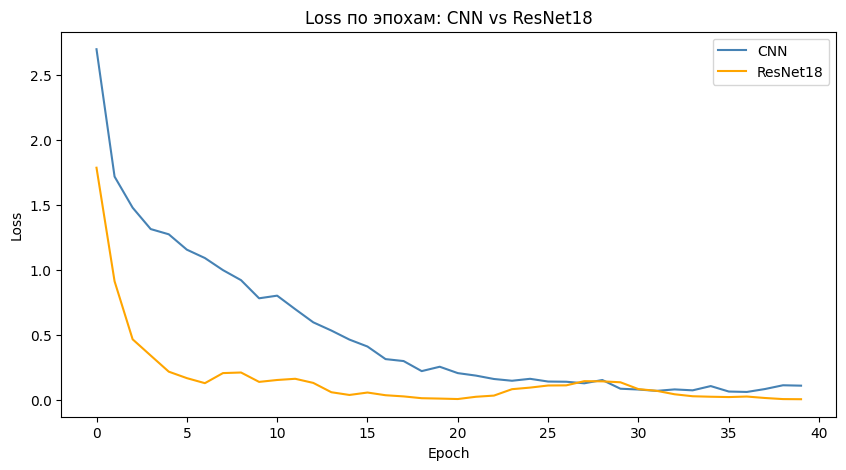

In [22]:
# ячейка 19 — Loss сравнение
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='CNN', color='steelblue')
plt.plot(train_losses_res, label='ResNet18', color='orange')
plt.title('Loss по эпохам: CNN vs ResNet18')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

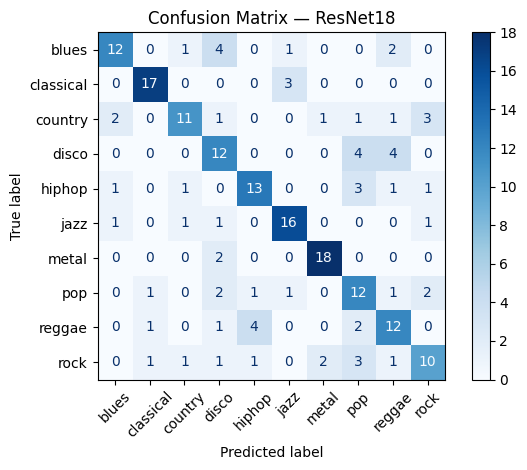

In [23]:
# ячейка 20 — Confusion Matrix для лучшей модели (ResNet18)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_res)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix — ResNet18')
plt.tight_layout()
plt.show()

In [24]:
# ячейка 21 — қорытынды
print("""
=== ҚОРЫТЫНДЫ ===

CNN (с нуля):
- Параметрлер: 2.2M
- Accuracy: {:.4f}
- F1-score: {:.4f}
- Metal жанрын жақсы таниды (recall 100%)

ResNet18 (Transfer Learning):
- Параметрлер: 11.2M
- Accuracy: {:.4f}
- F1-score: {:.4f}
- Барлық жанрларда тұрақты нәтиже

Жеңімпаз: ResNet18 ✅
Себебі: Transfer Learning алдын ала үйренген белгілерді
(edge, texture) пайдаланады, бұл кішкентай датасетте
(999 файл) үлкен артықшылық береді.
""".format(acc_cnn, f1_cnn, acc_res, f1_res))


=== ҚОРЫТЫНДЫ ===

CNN (с нуля):
- Параметрлер: 2.2M
- Accuracy: 0.6100
- F1-score: 0.5995
- Metal жанрын жақсы таниды (recall 100%)

ResNet18 (Transfer Learning):
- Параметрлер: 11.2M
- Accuracy: 0.6650
- F1-score: 0.6661
- Барлық жанрларда тұрақты нәтиже

Жеңімпаз: ResNet18 ✅
Себебі: Transfer Learning алдын ала үйренген белгілерді
(edge, texture) пайдаланады, бұл кішкентай датасетте
(999 файл) үлкен артықшылық береді.

